In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path

import pandas as pd
import numpy as np

from utils import DATA_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [3]:
pull_predictions_from_weka("aws")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_aws_predictions.parquet


In [4]:
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id', 'acc_per_char']
df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)
print(f'Loaded {len(df):,} instance predictions')

Loaded 114,524,590 instance predictions


In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()

print(MODELS)

['prox_fineweb_pro-150M-5xC', 'dolma17-75p-DCLM-baseline-25p-530M-5xC', 'dolma-v1-6-and-sources-baseline-750M-5xC', 'fineweb_edu_dedup-300M-5xC', 'fineweb_edu_dedup-1B-5xC', 'falcon-750M-5xC', 'falcon_and_cc_tulu_qc_top10-300M-5xC', 'fineweb_edu_dedup-750M-5xC', 'falcon-150M-5xC', 'no_math_no_code-1B-5xC', 'no_reddit-530M-5xC', 'redpajama-300M-5xC', 'falcon_and_cc-750M-5xC', 'no_code-750M-5xC', 'no_math_no_code-150M-5xC', 'falcon_and_cc_tulu_qc_top10-150M-5xC', 'falcon_and_cc-1B-5xC', 'dolma17-25p-DCLM-baseline-75p-530M-5xC', 'c4-750M-5xC', 'dolma17-25p-DCLM-baseline-75p-300M-5xC', 'falcon_and_cc_og_eli5_oh_top10p-1B-5xC', 'dolma17-50p-DCLM-baseline-50p-300M-5xC', 'DCLM-baseline-750M-5xC', 'no_flan-150M-5xC', 'baseline-300M-5xC', 'falcon_and_cc_og_eli5_oh_top10p-300M-5xC', 'dolma-v1-6-and-sources-baseline-150M-5xC', 'falcon_and_cc_eli5_oh_top10p-300M-5xC', 'falcon_and_cc_eli5_oh_top20p-300M-5xC', 'falcon_and_cc_og_eli5_oh_top10p-530M-5xC', 'falcon_and_cc_eli5_oh_top20p-530M-5xC', 'falc

### Sample Variance

In [6]:
from stats import compute_total_variation

import matplotlib.pyplot as plt

In [7]:
from utils.constants_tasks import RC_TASKS_OLMES

# Get task suites
olmes = [task.split('::')[0].replace(':rc', '') for task in RC_TASKS_OLMES if 'mmlu_' not in task]
TASKS  = df.index.get_level_values('task').unique().to_list()
MMLU  = [t for t in TASKS if 'mmlu' in t]

In [8]:
_MODELS = ['prox_fineweb_pro-1B-5xC', 'fineweb_edu_dedup-1B-5xC', 'DCLM-baseline-1B-5xC', 'c4-1B-5xC', 'dolma17-50p-DCLM-baseline-50p-1B-5xC']

Text(0.5, 1.0, 'Accuracy across training for 5 data mixes at 1B-5xC (BoolQ)')

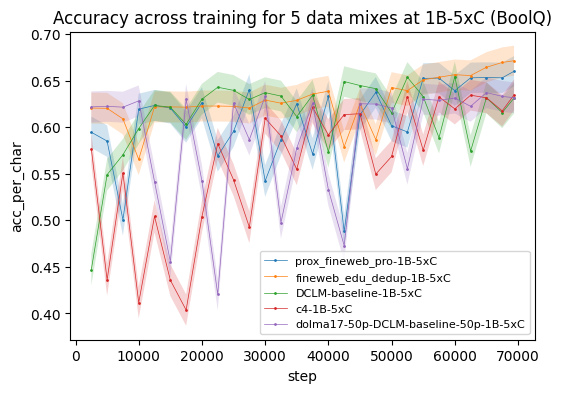

In [9]:
import math

metric='acc_per_char'

fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)

task = 'boolq'

ax = axes[0][0]

def calculate_standard_error(avg_score, num_scores):
    se_bernoulli = math.sqrt(avg_score * (1 - avg_score) / num_scores)
    return se_bernoulli


for model in _MODELS:
    step, scores = get_nd_array(df, 'step', metric, model=model, task=task)
    num_scores = scores.shape[1]
    acc = scores.mean(axis=1)

    step, acc = step[1:], acc[1:]
    ci = 1.96 * np.array([calculate_standard_error(acc_step, num_scores) for acc_step in acc])

    # ax.errorbar(step, acc, yerr=std_errors, label=model, linewidth=0.5, marker='.', markersize=2, capsize=3)
    ax.fill_between(step, acc - ci, acc + ci, alpha=0.2)

    ax.plot(step, acc, label=model, linewidth=0.5, marker='.', markersize=2)

ax.legend(fontsize=8)
ax.set_xlabel('step')
ax.set_ylabel('acc_per_char')
ax.set_title(f'Accuracy across training for {len(_MODELS)} data mixes at 1B-5xC (BoolQ)')